In [6]:
import ee
# 1. Autenticación (Te saldrá un enlace emergente, acéptalo con tu correo)
ee.Authenticate()

# 2. Inicializar el motor con tu nuevo proyecto
ee.Initialize(project='wildfire-sim-2026')

# 3. Definir el área de Pucallpa (Longitud Oeste, Latitud Sur, Longitud Este, Latitud Norte)
pucallpa= ee.Geometry.Rectangle([-74.65, -8.45, -74.45, -8.30])

# 4. Consultar Dynamic World (Datos satelitales recientes de las últimas semanas)
dw_coleccion = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
                .filterBounds(pucallpa)
                .filterDate('2026-08-01', '2026-09-20'))

# 5. Extraer la matriz clasificada
mapa_clasificado = dw_coleccion.mode().select('label').clip(pucallpa)

print("¡Matriz espacial de Pucallpa descargada en memoria desde la nube de Google!")

¡Matriz espacial de Pucallpa descargada en memoria desde la nube de Google!


In [3]:
import requests
import rasterio
from rasterio.io import MemoryFile
import numpy as np
# 1. Solicitar a Google el empaquetado del mapa a 10 metros de resolución
url = mapa_clasificado.getDownloadURL({
    'scale': 10,
    'crs': 'EPSG:4326',
    'region': pucallpa,
    'format': 'GEO_TIFF'
})
# 2. Descargar los binarios directamente a la RAM
respuesta = requests.get(url)

# 3. Decodificar la matriz usando rasterio en memoria
with MemoryFile(respuesta.content) as memfile:
    with memfile.open() as dataset:
        datos_leidos = dataset.read(1)

# 4. Validar la estructura para el autómata celular
print(f"¡Matriz lista para el autómata! Dimensiones: {datos_leidos.shape}")
print(f"Categorías de terreno detectadas: {np.unique(datos_leidos)}")

¡Matriz lista para el autómata! Dimensiones: (1670, 2227)
Categorías de terreno detectadas: [0 1 2 3 4 5 6 7 8]


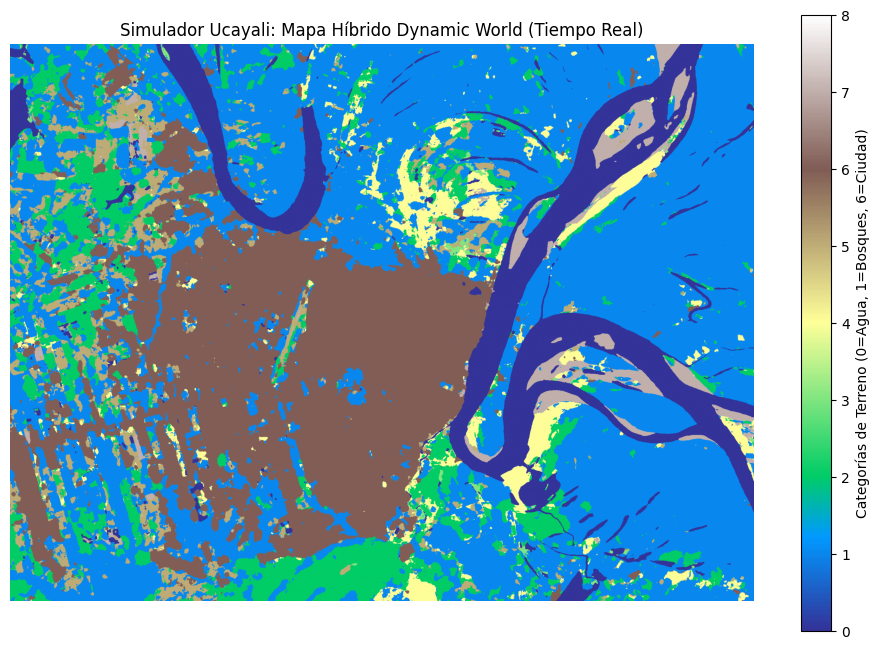

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
# Renderizamos la matriz de NumPy. Usamos vmin=0 y vmax=8 para fijar la escala de colores
mapa_visual = plt.imshow(matriz_numpy, cmap='terrain', vmin=0, vmax=8)
# Añadimos una barra de leyenda lateral
barra = plt.colorbar(mapa_visual, ticks=range(9))
barra.set_label('Categorías de Terreno (0=Agua, 1=Bosques, 6=Ciudad)')
plt.title('Simulador Ucayali: Mapa Híbrido Dynamic World (Tiempo Real)')
plt.axis('off') # Ocultamos los ejes para ver solo el mapa
plt.show()